# CURB - Emerging-Hotspot Trends
### notebook 04 - Problem Statement 1 (Parking-Induced Congestion)

The defensible **reactive -> proactive** layer: which spots got *worse* over the data
window, so enforcement can get ahead of them.

**Why this is trustworthy here:** citywide weekly volume is flat across the period (we
check this below - the second/first-half ratio is ~1.0). So a cell that rises is genuinely
rising, not riding a citywide ramp. We trim the two partial boundary weeks, split the rest
into first vs second half, and measure each cell's growth **relative to the city**.

**Honesty (for the deck):** this is a *retrospective* trend over ~5 months, not a future
forecast. Dates were shifted by a constant offset in anonymisation (relative trends valid,
absolute dates not); hour-of-day is unreliable and unused. Provided dataset only.

In [1]:
import os, sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.py").exists() and (REPO_ROOT.parent / "config.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT)); os.chdir(REPO_ROOT)
import config, pandas as pd, matplotlib.pyplot as plt
from src.trends import run
DATA_PATH = config.DATA_PATH
pd.set_option("display.max_colwidth", 34)
print("data:", DATA_PATH, "exists:", os.path.exists(DATA_PATH))

data: data/violations.csv exists: True


## 1 - Run + validity check

In [2]:
cell, emerging, city_ratio = run(DATA_PATH)
print(f"Citywide second/first-half ratio: {city_ratio:.3f}  (near 1.0 => flat baseline, trends are real)")
print(f"{len(cell):,} cells assessed (>=20 citations)")
print(cell.trend.value_counts().to_string())

[data] loaded 298,450 rows -> 248,376 usable after cleaning


c:\Users\ARPIT\Downloads\curb_source\curb\src\trends.py:64: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = dt.dt.to_period("W")


Citywide second/first-half ratio: 1.011  (near 1.0 => flat baseline, trends are real)
2,092 cells assessed (>=20 citations)
trend
Stable      807
Cooling     660
Emerging    625


## 2 - The trend split

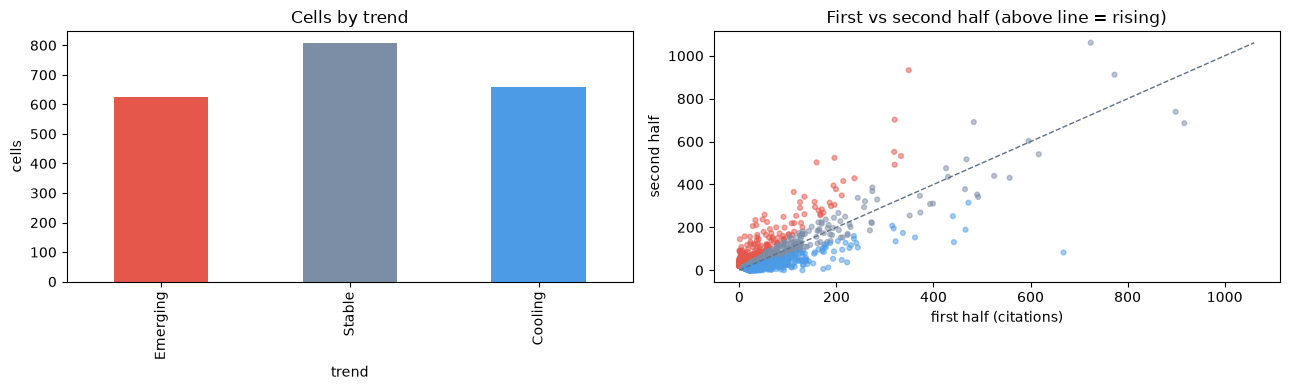

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cell.trend.value_counts().reindex(["Emerging","Stable","Cooling"]).plot.bar(
    ax=ax[0], color=["#E5564B","#7C8DA6","#4C9BE6"])
ax[0].set_title("Cells by trend"); ax[0].set_ylabel("cells")
ax[1].scatter(cell["first"], cell["second"], s=12,
              c=cell.trend.map({"Emerging":"#E5564B","Stable":"#7C8DA6","Cooling":"#4C9BE6"}), alpha=.5)
lim = max(cell["first"].max(), cell["second"].max())
ax[1].plot([0, lim], [0, lim], "--", color="#5E6F8A", linewidth=1)
ax[1].set_xlabel("first half (citations)"); ax[1].set_ylabel("second half")
ax[1].set_title("First vs second half (above line = rising)")
plt.tight_layout(); plt.show()

## 3 - Top emerging hotspots (biggest real rise)

In [4]:
emerging.head(12)[["rank","name","first","second","change","rel_growth","total","impact_score"]]

,rank,name,first,second,change,rel_growth,total,impact_score
0,1,"Sahakar Nagar Road, Fortuna A...",349,933,584,2.64,1282,881.4
1,2,BTP082 - KR Market Junction,320,702,382,2.17,1022,1088.4
2,3,"Sahakar Nagar Road, Fortuna A...",159,503,344,3.13,662,548.3
3,4,"Sahakar Nagar Road, Fortuna A...",196,524,328,2.64,720,550.8
4,5,BTP082 - KR Market Junction,112,365,253,3.22,477,527.4
5,6,"BTP001 - 10th Cross, Dr. Rajku...",319,552,233,1.71,871,1184.3
6,7,"Sahakar Nagar Road, Olivia",134,343,209,2.53,477,341.9
7,8,"Neeladri Road, Neeladri Nagar",52,259,207,4.93,311,254.4
8,9,BTP082 - KR Market Junction,214,416,202,1.92,630,686.4
9,10,"Outer Ring Road, Soulspace Pa...",33,234,201,7.01,267,1307.4


### The priority watchlist: rising **and** already high-impact
Sort the emerging spots by impact - these aren't just trending up, they already carry real
obstruction burden. This is the "get ahead of it" list.

In [5]:
emerging.sort_values("impact_score", ascending=False).head(10)[
    ["name","first","second","change","rel_growth","impact_score"]]

,name,first,second,change,rel_growth,impact_score
10,"Kadubeesanahalli Underpass, K...",194,395,201,2.01,2997.5
40,"Outer Ring Road, Venkatappa C...",189,299,110,1.56,1643.4
42,"Unnamed Road, Begur Chikkanah...",196,305,109,1.54,1543.9
51,"Old Madras Road, Royal Heritage",167,262,95,1.55,1488.1
9,"Outer Ring Road, Soulspace Pa...",33,234,201,7.01,1307.4
5,"BTP001 - 10th Cross, Dr. Rajku...",319,552,233,1.71,1184.3
1,BTP082 - KR Market Junction,320,702,382,2.17,1088.4
13,"MBT Road, Devasandra Junction",237,429,192,1.79,972.7
0,"Sahakar Nagar Road, Fortuna A...",349,933,584,2.64,881.4
47,"Vibgyor High School Road, Sam...",40,145,105,3.58,772.6


## 4 - Cooling spots (for contrast)\nSome big spots are improving - useful to show enforcement effort isn't static.

In [6]:
cell[cell.trend == "Cooling"].sort_values("change").head(10)[
    ["name","first","second","change","rel_growth","impact_score"]]

,name,first,second,change,rel_growth,impact_score
2091,BTP032 - Windsor Circle,668,83,-585,0.12,480.2
2090,BTP027 - Modi Bridge Junction,442,131,-311,0.29,517.1
2089,"Pusa Thippasandra Main Road, ...",466,189,-277,0.40,681.2
2087,BTP057 - Anand Rao Junction,362,153,-209,0.42,914.3
2086,BTP051 - Safina Plaza Junction,440,252,-188,0.57,506.6
2085,BTP045 - Danvanthri Road Junction,322,135,-187,0.41,647.2
2084,"Markham Road, St Patricks Com...",222,37,-185,0.16,194.4
2083,"BTP033 - Sophia High School, S...",183,13,-170,0.07,126.1
2082,BTP020 - Hosahalli Metro Station,173,6,-167,0.03,114.9
2080,"Kadubeesanahalli Underpass, K...",337,174,-163,0.51,2305.3


## 5 - Files written

In [7]:
for f in ["outputs/curb_trends.json","outputs/curb_trends.csv"]:
    print("wrote", f, "-", os.path.getsize(f), "bytes")
j = json.load(open("outputs/curb_trends.json"))
print("\nmeta:", json.dumps(j["meta"], indent=2))

wrote outputs/curb_trends.json - 90251 bytes
wrote outputs/curb_trends.csv - 173754 bytes

meta: {
  "city_second_over_first": 1.011,
  "cells_assessed": 2092,
  "emerging": 625,
  "cooling": 660,
  "note": "Retrospective trend over the data window (NOT a forecast); measured relative to the flat citywide baseline; provided dataset only."
}


## Methodology note
- Trend = second-half vs first-half citations per cell, over the trimmed window
  (partial start/end weeks removed), normalised against the flat citywide baseline.
- "Emerging" requires rising >1.5x the citywide rate AND a minimum absolute increase, so
  tiny noisy cells are excluded (thresholds are documented constants in `src/trends.py`).
- Retrospective trend, not a forecast. Provided dataset only; hour-of-day not used.